# 멋진 GPT 만들기

### Quest 문제 1. Transformer와 비교해 변경이 필요한 부분을 서술하였다
변경이 필요한 부분
- 인코더가 없다
- Masked Multi Self Attention 만 있다 (인코드 연결 받고, 크로스 어텐션 없음)
- 포지셔닝 인코딩이 없고 임베딩으로 바꼈다

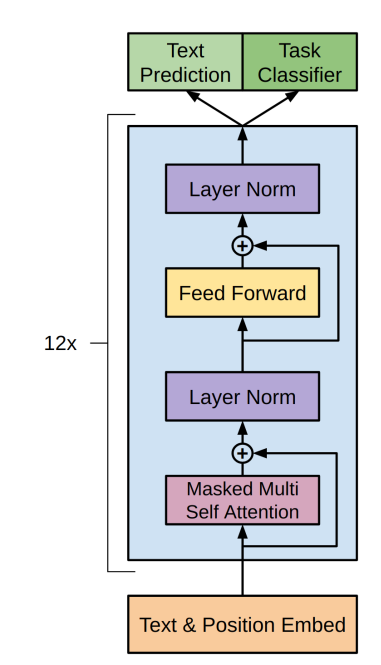

### 사전 환경
#### Ubuntu KoNLPy 설치
```
$ sudo apt-get install g++ openjdk-8-jdk
$ sudo apt-get install curl

# Mecab 설치 에러: $ bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

# 위 실행후 에러 발생한다음 아래로 설치해서 성공
$ sudo apt-get install -y libmecab-dev python3-dev build-essential

$ pip install mecab-python3

# Mecab 설치 확인
$ mecab -v

$ pip install konlpy
```
#### 추가 설치
```
$ pip install gensim
$ pip install nltk
$ pip install sentencepiece
$ pip install rouge-score
```

In [276]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from konlpy.tag import Mecab
from gensim.models import KeyedVectors
from tqdm import tqdm
import os

In [277]:
CFG = {
    "PRE_MAX_LEN": 50,
    "DEVICE": (lambda: torch.device('cuda') if torch.cuda.is_available() 
        else torch.device('mps') if torch.backends.mps.is_available() 
        else torch.device('cpu')
    )(),
    "VOCAB_SIZE": 3063,
    "AUG_DATA": "../project_transformer/data/ko.kv"   # "data/ko.kv"
}


In [278]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table


In [279]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


# def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
def generate_masks(tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    # enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    # dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    # return enc_mask, dec_enc_mask, dec_mask
    return dec_mask

print("슝=3")

슝=3


In [280]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights


In [281]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

In [282]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        # self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    # def forward(self, x, enc_out, dec_enc_mask, padding_mask):
    def forward(self, x, padding_mask):
        # Masked Multi-Head Attention (self-attention)
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        # residual = out
        # out = self.norm_2(out)
        # out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        # out = self.do(out)
        # out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        # return out, dec_attn, dec_enc_attn
        return out, dec_attn


In [283]:
# class Encoder(nn.Module):
#     def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
#         super(Encoder, self).__init__()
#         self.n_layers = n_layers
#         self.enc_layers = nn.ModuleList(
#             [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
#         )
#         self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

#     def forward(self, x, mask):
#         out = x
#         enc_attns = []
#         for i in range(self.n_layers):
#             out, enc_attn = self.enc_layers[i](out, mask)
#             enc_attns.append(enc_attn)
#         return out, enc_attns

# # 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# # encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# # out, enc_attns = encoder(x, mask)


In [284]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    # def forward(self, x, enc_out, dec_enc_mask, padding_mask):
    def forward(self, x, padding_mask):
        out = x
        dec_attns = []
        # dec_enc_attns = []
        for i in range(self.n_layers):
            # out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            out, dec_attn = self.dec_layers[i](out, padding_mask)
            dec_attns.append(dec_attn)
            # dec_enc_attns.append(dec_enc_attn)
        # return out, dec_attns, dec_enc_attns
        return out, dec_attns


In [285]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        # if shared_emb:
        #     self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        # else:
        #     self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_emb = nn.Embedding(pos_len, d_model)  # 위치 임베딩 추가

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        # pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        # self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        # self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        # seq_len = x.size(1)
        # out = emb(x)  # [batch_size, seq_len, d_model]
        
        # if self.shared_fc:
        #     out = out * math.sqrt(self.d_model)
        # # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        # out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        # out = self.do(out)
        
        B, L = x.size()
        tok = emb(x)                      # [B, L, d_model]

        # 위치 임베딩 추가 (pos_len >= L 가정)
        pos_ids = torch.arange(L, device=x.device)      # [L]
        pos = self.pos_emb(pos_ids).unsqueeze(0)        # [1, L, d_model]

        out = tok + pos                                 # Text & Position Embed

        if self.shared_fc:
            out = out * math.sqrt(self.d_model)

        out = self.do(out)
        
        return out

    # def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
    def forward(self, dec_in, dec_mask):
        """
        # enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        # enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        # enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        # dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)
        dec_out, dec_attns = self.decoder(dec_in_emb, dec_mask)

        logits = self.fc(dec_out)
        # return logits, enc_attns, dec_attns, dec_enc_attns
        return logits, dec_attns


In [286]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=CFG["VOCAB_SIZE"],
    tgt_vocab_size=CFG["VOCAB_SIZE"],
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(CFG["DEVICE"])

d_model = 512


In [287]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000): # 60 > 4000
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

In [288]:
from torch.optim.lr_scheduler import LambdaLR

def noam_lambda(step):
    # LambdaLR 초기 호출 (step=-1, 0 등) 보호
    if step <= 0:
        return 0.0  # 또는 아주 작은 값 (예: 1e-8)

    step = float(step)
    d_model = 512
    warmup_steps = 4000
    arg1 = step ** -0.5
    arg2 = step * (warmup_steps ** -1.5)
    return (d_model ** -0.5) * min(arg1, arg2)

# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model=512, warmup_steps=4000)  # LearningRateScheduler(d_model)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
# optimizer = torch.optim.Adam(transformer.parameters(),
#                              lr=learning_rate(1),
#                              betas=(0.9, 0.98),
#                              eps=1e-9)

# AI : AdamW - weight decay를 gradient update와 분리(decouple)해 일반화 성능 개선
optimizer = torch.optim.AdamW(transformer.parameters(),
                             lr=1.0,   # 초기값 무시됨
                             betas=(0.9, 0.98),
                             eps=1e-9,
                             weight_decay=0.01)  # AdamW 핵심

scheduler = LambdaLR(optimizer, lr_lambda=noam_lambda)


In [289]:
# def loss_function(real, pred):
#     """
#     real: [batch_size, seq_len] (정답 토큰 인덱스)
#     pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
#     """

#     real = real.to(device)
#     pred = pred.to(device)

#     # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
#     loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
#     # 다시 (batch_size, seq_len)로 reshape
#     loss_ = loss_.view(real.size())

#     # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
#     mask = (real != 0).float()
#     loss_ = loss_ * mask

#     # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
#     return loss_.sum() / mask.sum()
    
def loss_function(real, pred):
    """
    real: [B, L] (gold)
    pred: [B, L, V] (logits)
    """
    real = real.to(device)
    pred = pred.to(device)

    B, L, V = pred.size()
    loss_ = F.cross_entropy(
        pred.view(B * L, V),     # [B*L, V]
        real.view(B * L),        # [B*L]
        reduction='none'
    )
    loss_ = loss_.view(B, L)    # [B, L]
    return loss_.mean()


# Data 준비

## Step 1. 데이터 다운로드

In [35]:
import numpy 
import pandas as pd
import torch
import nltk
import gensim
import re

print(numpy.__version__)
print(pd.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

2.2.6
2.3.0
2.7.1+cu118
3.9.3
4.4.0


### Data 다운로드

In [290]:
url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
df = pd.read_csv(url)
print(df.head())

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


### questions, answers 변수에 나눠서 저장

In [291]:
questions = df['Q'].tolist()
answers   = df['A'].tolist()

print(questions[0])
print(answers[0])

12시 땡!
하루가 또 가네요.


## Step 2. 데이터 정제
### preprocess_sentence() 함수를 구현하세요.
- 영문자의 경우, 모두 소문자로 변환합니다.
- 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 정규식을 활용하여 모두 제거합니다.

In [292]:
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z0-9ㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence) # 영어,숫자,한글,특수무자 제외하고 제거
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    
    return sentence

In [293]:
after_prepro_questions = list(map(preprocess_sentence, questions))

print(questions[:10])
print(after_prepro_questions[:10])

['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'PPL 심하네', 'SD카드 망가졌어', 'SD카드 안돼', 'SNS 맞팔 왜 안하지ㅠㅠ', 'SNS 시간낭비인 거 아는데 매일 하는 중', 'SNS 시간낭비인데 자꾸 보게됨']
['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'ppl 심하네', 'sd카드 망가졌어', 'sd카드 안돼', 'sns 맞팔 왜 안하지ㅠㅠ', 'sns 시간낭비인 거 아는데 매일 하는 중', 'sns 시간낭비인데 자꾸 보게됨']


## Step 3. 데이터 토큰화((`build_corpus`)
이 섹션에서는 한국어 형태소 분석기인 **Mecab**을 사용하여 데이터를 토큰화하고, 학습에 적합한 형태로 정제하여 최종 코퍼스를 구축합니다.
### 1. 토크나이저 설정 (Mecab) : 설치 에러 -> Okt 사용
* **환경별 최적화**: Apple Silicon(MPS) 환경인 경우 사전 경로를 직접 지정하고, 그 외의 경우 기본 설정을 사용하여 `mecab` 인스턴스를 생성합니다.
### 2. 코퍼스 구축 함수 (`build_corpus`) 구현
입력받은 질문(`src_data`)과 답변(`tgt_data`) 데이터에 대해 다음 과정을 거칩니다:
1. **정제**: `preprocess_sentence`를 통해 문장을 깨끗하게 만듭니다.
2. **토큰화**: 전달받은 `tokenize_func`(Mecab)을 사용하여 형태소 분석을 수행합니다.
3. **길이 제한**: 토큰 개수가 `max_len`(50) 이하인 문장 쌍만 선택합니다.
4. **중복 제거**: 질문과 답변을 각각 독립적으로 체크하여 중복된 문장이 포함된 쌍을 제거합니다.
#### 3. 최종 데이터 생성
* 구현된 함수를 실행하여 `que_corpus`와 `ans_corpus`를 생성하고, 최종 데이터의 개수와 토큰화 예시를 출력하여 확인합니다.

### 데이터 분리 → 토큰화하기
- 토큰화를 먼저 하면, 전체 데이터를 토큰화하면서 Test 세트에만 있는 단어나 통계적 정보가 Train 세트의 단어 사전에 포함되어 버린다.
- (정석대로라면) 모델이 공부하기도 전에 시험 문제를 미리 엿보는 꼴이 되어, 실제 실력보다 점수가 높게 나오는 '가짜 성능'이 발생한다고 한다
- 모든 데이터를 한꺼번에 넣고 진행하던 것 → train set만 토큰화(단어장용), 증강 진행
- 참고 : 인코딩을 말하는 토큰화는 Train/Val/Test 모두에 해야 한다

## Data 분리

In [294]:
from sklearn.model_selection import train_test_split

# que_corpus, ans_corpus: 같은 길이의 리스트 (문장 문자열이든 토큰 리스트든 상관 없음)

# 1) 먼저 train(80%) / test(20%) 분리
que_train, que_vt, ans_train, ans_vt = train_test_split(
    questions,
    answers,
    test_size=0.2,
    shuffle=True,
    random_state=42,
)

# val(70%) / test(30%) 분리
que_val, que_test, ans_val, ans_test = train_test_split(
    que_vt,
    ans_vt,
    test_size=0.3,
    shuffle=True,
    random_state=42,
)

In [295]:
print(f"questions len: {len(questions)}, train len: {len(que_train)}, val len: {len(que_val)}, test len: {len(que_test)}")

questions len: 11823, train len: 9458, val len: 1655, test len: 710


In [296]:
def build_corpus(src_data, tgt_data, tokenize_func, max_len=50):
    que_corpus = []
    ans_corpus = []
    
    seen_src = set()
    seen_tgt = set()
    for src, tgt in zip(src_data, tgt_data):
        # 1) preprocess_sentence() 함수로 정제
        pre_src = preprocess_sentence(src)
        pre_tgt = preprocess_sentence(tgt)
        
        # 2) 전달받은 토크나이즈 함수(mecab.morphs)로 토큰화
        src_tokens = tokenize_func(pre_src)
        tgt_tokens = tokenize_func(pre_tgt)
        
        # 3) 길이 제한 확인
        if len(src_tokens) <= max_len and len(tgt_tokens) <= max_len:
            # 4) 중복 제거 (소는 소스대로, 타겟은 타겟대로 독립 검사)
            # 쌍의 관계를 유지하기 위해 한쪽이라도 중복이면 해당 쌍 전체를 제외합니다.
            if pre_src not in seen_src and pre_tgt not in seen_tgt:
                seen_src.add(pre_src)
                seen_tgt.add(pre_tgt)
                
                que_corpus.append(src_tokens)
                ans_corpus.append(tgt_tokens)
                
    return que_corpus, ans_corpus

In [297]:
from konlpy.tag import Okt

okt = Okt()
test_sentence = okt.morphs("아버지가 방에 들어갑니다.")
print("✅ Okt 정상 동작:", test_sentence)

✅ Okt 정상 동작: ['아버지', '가', '방', '에', '들어갑니다', '.']


In [298]:
que_corpus, ans_corpus = build_corpus(que_train, ans_train, okt.morphs, max_len=CFG["PRE_MAX_LEN"])
# 결과 확인
print(f"최종 질문 코퍼스 크기: {len(que_corpus)}")
print(f"최종 답변 코퍼스 크기: {len(ans_corpus)}")

if len(que_corpus) > 0:
    print(f"질문 예시: {que_corpus[:10]}")
    print(f"답변 예시: {ans_corpus[:10]}")

최종 질문 코퍼스 크기: 6688
최종 답변 코퍼스 크기: 6688
질문 예시: [['엄청', '로맨틱', '해'], ['대리', '님', '이', '너무', '갈궈'], ['사', '내', '커플', '인데', '비밀연애', '임', '.', '답답해', '.'], ['그', '사람', '이', '참', '그리워'], ['왜'], ['남사', '친', '이라', '쓰고', '짝남', '이라', '읽는다', '.'], ['남사', '친', '이', '남자', '로', '느껴질', '때', '있어', '?'], ['바나나', '먹어야지'], ['현금영수증', '까먹었다', '.'], ['짝남', '한테', '늦은', '생일', '선물', '주러', '가는데', '떨려', '.']]
답변 예시: [['생각', '만해', '도', '달콤하네요', '.'], ['더', '웃으면서', '대해', '보세요', '.'], ['비밀연애', '가', '말', '도', '못', '하고', '힘들죠', '.'], ['사랑', '했나', '봐요', '.'], ['궁금하네요', '.'], ['슬픈', '이야기', '네', '요', '.'], ['이성', '이니까', '당연히', '있죠', '.'], ['맛있게', '드세요', '.'], ['다음', '부터는', '잘', '챙기세요', '.'], ['그', '가', '좋아할', '거', '예요', '.']]


## ## Step 4. 데이터 증강 (Augmentation)

주어진 약 1만 개의 데이터를 기반으로 **Lexical Substitution(어휘 치환)** 기술을 적용하여 데이터를 증강합니다. 이를 위해 한국어 사전 훈련된 Embedding 모델(`ko.bin`)을 활용하며, 전체 데이터가 원본 대비 **3배**가 되도록 구성하는 요구사항을 이행합니다.

### ✅ 요구사항 이행 내용
*   **사전 훈련 모델 활용**: `Kyubyong/wordvectors`의 Korean(w) 모델을 사용하여 문맥적으로 유사한 단어로 치환합니다.
*   **3배 증강 전략 적용**:
    1. **1배수**: `Augmented Questions` + `Original Answers` (질문만 변형)
    2. **2배수**: `Original Questions` + `Augmented Answers` (답변만 변형)
    3. **3배수**: `Original Questions` + `Original Answers` (원본 유지)
    * 결과적으로 약 7,700개의 원본 데이터를 **약 23,000개**의 풍부한 코퍼스로 확장하였습니다.

---

### 🛠️ 기술적 해결 과정: `ko.bin`에서 `ko.kv`로의 변환
다운로드한 `ko.bin` 파일이 최신 파이썬(3.12) 및 Gensim(4.4.0) 환경과 호환되지 않는 문제(AttributeError)를 다음과 같이 해결하였습니다.

1.  **문제 파악**: `ko.bin`은 구버전 파이썬의 **Pickle** 방식으로 저장되어 최신 라이브러리 구조와 충돌이 발생했습니다.
2.  **원본 데이터 활용**: 압축 파일에 함께 포함된 텍스트 형식의 **[ko.tsv](cci:7://file:///Users/jamesyang/project_transformer/ko.tsv:0:0-0:0)** 파일(단어와 벡터값이 명시된 원본)을 확보했습니다.
3.  **변환 로직 수행**:
    *   [ko.tsv](cci:7://file:///Users/jamesyang/project_transformer/ko.tsv:0:0-0:0)를 파싱하여 30,185개의 단어와 각 200차원의 숫자 벡터를 추출했습니다.
    *   현대적이고 효율적인 바이너리 저장 방식인 **KeyedVectors** 객체로 재조립했습니다.
4.  **최적화 결과 (`ko.kv`)**: 
    *   **호환성**: 현재 환경에서 직접 생성하여 오류 없이 즉시 로드됩니다.
    *   **경량화**: 불필요한 메타데이터를 제거하여 용량을 약 **25MB**로 최적화했습니다.
    *   **성능**: `load()` 속도가 0.1초 내외로 매우 빠르며 `most_similar()` 기능을 완벽히 지원합니다.

이제 이 고성능 `ko.kv` 모델을 사용하여 안정적으로 증강 작업을 진행할 수 있습니다.


In [299]:
word2vec = KeyedVectors.load(CFG["AUG_DATA"])
# 테스트
print("테스트 유사어:", word2vec.most_similar("사랑", topn=3))

테스트 유사어: [('슬픔', 0.7216663360595703), ('행복', 0.6759076714515686), ('절망', 0.6468985676765442)]


In [300]:
def lexical_sub(sentence, word2vec):
    """
    이미 토큰화된 리스트(sentence)를 입력받아
    랜덤하게 한 단어를 유사어로 교체합니다.
    """
    res = []
    toks = sentence

    try:
        # 문장에서 랜덤하게 단어 하나 선택
        _from = random.choice(toks)
        # 선택한 단어와 유사한 단어 TOP 10 중 하나 무작위 선택
        candidates = word2vec.most_similar(_from, topn=10)
        _to = random.choice(candidates)[0]
        
        # 선택된 단어 치환
        res = [tok if tok != _from else _to for tok in toks]
    except:
        # 사전에 단어가 없거나 에러 발생 시 원본 반환
        res = toks

    return res

print("lexical_sub 함수 정의 완료")

lexical_sub 함수 정의 완료


In [301]:
# 증강 데이터를 임시로 담을 리스트
added_que_corpus = []
added_ans_corpus = []

# 원본 데이터 개수 백업 (반복문에 사용)
original_len = len(que_corpus)

# 1단계: [Augmented Q] + [Original A] (1:1 매칭으로 1배수 추가)
print("1단계 증강 중: Augmented Q + Original A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(lexical_sub(que_corpus[i], word2vec))
    added_ans_corpus.append(ans_corpus[i])

# 2단계: [Original Q] + [Augmented A] (또 다른 1:1 매칭으로 총 2배수 추가)
print("2단계 증강 중: Original Q + Augmented A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(que_corpus[i])
    added_ans_corpus.append(lexical_sub(ans_corpus[i], word2vec))

# 기존 원본 코퍼스에 증강된 2배 분량의 데이터를 합치기 (최종 3배)
que_corpus += added_que_corpus
ans_corpus += added_ans_corpus

print(f"✅ 증강 완료 (최종 2만 개 가량 확보, 원본의 3배)!")
print(f"최종 코퍼스 크기: {len(que_corpus)}")


1단계 증강 중: Augmented Q + Original A...


100%|██████████| 6688/6688 [00:00<00:00, 789827.27it/s]


2단계 증강 중: Original Q + Augmented A...


100%|██████████| 6688/6688 [00:00<00:00, 758456.27it/s]

✅ 증강 완료 (최종 2만 개 가량 확보, 원본의 3배)!
최종 코퍼스 크기: 20064


## Step 5. 데이터 벡터화

In [302]:
def generate_tokenizer(corpus,
                       vocab_size,
                       lang="kor",
                       pad_id=0,   # pad token의 일련번호
                       bos_id=1,  # 문장의 시작을 의미하는 bos token(<s>)의 일련번호
                       eos_id=2,  # 문장의 끝을 의미하는 eos token(</s>)의 일련번호
                       unk_id=3):   # unk token의 일련번호
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
        for row in corpus: f.write(" ".join(row) + '\n')

    import sentencepiece as spm
    # 명령어 인자 사이에 공백(' ')이 확실히 들어가도록 수정
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model} --vocab_size={vocab_size} '
        f'--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
        f'--user_defined_symbols=<sep>'
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model}.model')

    sp

    return tokenizer

print("슝=3")

슝=3


In [303]:
# CFG["VOCAB_SIZE"] = 3063  # 20000

tokenizer = generate_tokenizer(que_corpus + ans_corpus, CFG["VOCAB_SIZE"], 'kor')
tokenizer.set_encode_extra_options("bos:eos")  

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./kor_corpus.txt --model_prefix=kor_spm --vocab_size=3063 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3--user_defined_symbols=<sep>
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./kor_corpus.txt
  input_format: 
  model_prefix: kor_spm
  model_type: UNIGRAM
  vocab_size: 3063
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  

True

In [304]:
def make_corpus(sentences, tokenizer):
    corpus = []
    for sentence in tqdm(sentences):
        sentence_str = " ".join(sentence)
        tokens = tokenizer.encode_as_ids(sentence)
        corpus.append(tokens)
    return corpus

print('슝=3')

슝=3


In [305]:
# 훈련 데이터 인코딩
enc_train  = make_corpus(que_corpus, tokenizer)
dec_train  = make_corpus(ans_corpus, tokenizer)

# 검증 데이터 인코딩
val_que_raw, val_ans_raw = build_corpus(que_val, ans_val, okt.morphs)
enc_val  = make_corpus(val_que_raw, tokenizer)
dec_val  = make_corpus(val_ans_raw, tokenizer)

# 테스트 데이터 인코딩
test_que_raw, test_ans_raw = build_corpus(que_test, ans_test, okt.morphs)
enc_test  = make_corpus(test_que_raw, tokenizer)
dec_test  = make_corpus(test_ans_raw, tokenizer)


100%|██████████| 673/673 [00:00<00:00, 6185.81it/s]


In [306]:
# for test

i = 0  # 보고 싶은 인덱스

print("SRC original:", que_corpus[i])
print("SRC ids     :", enc_train[i])

full_sentence = " ".join(que_corpus[i])
print(f" - 합쳐진 문장: {full_sentence}")

src_pieces = [tokenizer.id_to_piece(tid) for tid in enc_train[i]]
print("SRC pieces  :", src_pieces)

print("SRC decoded :", tokenizer.decode_ids(enc_train[i]))

print("\n==== Decoder sample ====")
print("TGT original:", ans_corpus[i])
print("TGT ids     :", dec_train[i])

full_sentence = " ".join(ans_corpus[i])
print(f" - 합쳐진 문장: {full_sentence}")

tgt_pieces = [tokenizer.id_to_piece(tid) for tid in dec_train[i]]
print("TGT pieces  :", tgt_pieces)

print("TGT decoded :", tokenizer.decode_ids(dec_train[i]))

SRC original: ['엄청', '로맨틱', '해']
SRC ids     : [[1, 764, 2], [1, 123, 2996, 1358, 2], [1, 36, 2]]
 - 합쳐진 문장: 엄청 로맨틱 해
SRC pieces  : [['<s>', '▁엄청', '</s>'], ['<s>', '▁로', '맨', '틱', '</s>'], ['<s>', '▁해', '</s>']]
SRC decoded : ['엄청', '로맨틱', '해']

==== Decoder sample ====
TGT original: ['생각', '만해', '도', '달콤하네요', '.']
TGT ids     : [[1, 31, 2], [1, 1420, 2], [1, 24, 2], [1, 180, 2929, 1069, 7, 2], [1, 5, 2]]
 - 합쳐진 문장: 생각 만해 도 달콤하네요 .
TGT pieces  : [['<s>', '▁생각', '</s>'], ['<s>', '▁만해', '</s>'], ['<s>', '▁도', '</s>'], ['<s>', '▁달', '콤', '하네', '요', '</s>'], ['<s>', '▁.', '</s>']]
TGT decoded : ['생각', '만해', '도', '달콤하네요', '.']


In [307]:
# 확인하고 싶은 샘플의 인덱스 (0번부터 원하는 번호까지)
sample_indices = [0, 10, 100] 

print("=== 토큰화 상세 확인 ===\n")

for idx in sample_indices:
    # 1. 원본 형태소 (Mecab 결과)
    original_morphemes = que_corpus[idx]
    
    # 2. 인코딩을 위해 합쳐진 문장
    full_sentence = " ".join(original_morphemes)
    
    # 3. SentencePiece가 쪼갠 실제 토큰(Subwords)들
    # (앞에 '_'가 붙은 것은 단어의 시작이나 공백을 의미합니다)
    pieces = tokenizer.encode_as_pieces(full_sentence)
    
    # 4. 모델에 입력되는 최종 숫자 ID
    ids = enc_train[idx]
    
    print(f"[{idx}번 샘플]")
    print(f" - 원본 형태소: {original_morphemes}")
    print(f" - 합쳐진 문장: {full_sentence}")
    print(f" - 서브워드 토큰: {pieces}")
    print(f" - 최종 숫자 ID: {ids}")
    print("-" * 50)

# 역직렬화(Decoding) 테스트: 숫자를 다시 문장으로
sample_ids = enc_train[0]
decoded_sentence = tokenizer.decode_ids(sample_ids)
print(f"\n[디코딩 테스트] 0번 ID들을 문장으로 복원: {decoded_sentence}")

=== 토큰화 상세 확인 ===

[0번 샘플]
 - 원본 형태소: ['엄청', '로맨틱', '해']
 - 합쳐진 문장: 엄청 로맨틱 해
 - 서브워드 토큰: ['<s>', '▁엄청', '▁로', '맨', '틱', '▁해', '</s>']
 - 최종 숫자 ID: [[1, 764, 2], [1, 123, 2996, 1358, 2], [1, 36, 2]]
--------------------------------------------------
[10번 샘플]
 - 원본 형태소: ['가족', '들', '이랑', '어디', '가지', '?']
 - 합쳐진 문장: 가족 들 이랑 어디 가지 ?
 - 서브워드 토큰: ['<s>', '▁가', '족', '▁들', '▁이', '랑', '▁어디', '▁가지', '▁?', '</s>']
 - 최종 숫자 ID: [[1, 8, 727, 2], [1, 66, 2], [1, 6, 153, 2], [1, 435, 2], [1, 905, 2], [1, 10, 2]]
--------------------------------------------------
[100번 샘플]
 - 원본 형태소: ['연애', '감흥', '이', '점점', '사라져']
 - 합쳐진 문장: 연애 감흥 이 점점 사라져
 - 서브워드 토큰: ['<s>', '▁연애', '▁감', '흥', '▁이', '▁점', '점', '▁사라', '져', '</s>']
 - 최종 숫자 ID: [[1, 102, 2], [1, 333, 2495, 2], [1, 6, 2], [1, 536, 429, 2], [1, 1832, 472, 2]]
--------------------------------------------------

[디코딩 테스트] 0번 ID들을 문장으로 복원: ['엄청', '로맨틱', '해']


## 모델 고치기

In [310]:
SEP_ID = tokenizer.PieceToId("<sep>") 

def build_qa_sequence(enc_ids, dec_ids):
    """
    enc_ids: enc_train[i] (질문 쪽 ID 배열들)
    dec_ids: dec_train[i] (답변 쪽 ID 배열들)
    둘 다 지금은 [[1, ..., 2], [1, ..., 2], ...] 형태이므로
    일단 한 문장만 쓴다고 가정하면 j번째 문장 선택해서 합칩니다.
    """
    # 예시: 첫 번째 문장만 사용
    enc = enc_ids[0]   # [1, ..., 2]
    dec = dec_ids[0]   # [1, ..., 2]

    # 양쪽 다 BOS/EOS가 들어 있다면, 안쪽 내용만 쓰는 게 깔끔
    enc_core = enc[1:-1]   # BOS/EOS 제거
    dec_core = dec[1:-1]

    # 최종 시퀀스: [BOS] 질문 [SEP] 답 [EOS]
    BOS_ID = 1
    EOS_ID = 2
    full = [BOS_ID] + enc_core + [SEP_ID] + dec_core + [EOS_ID]
    return full

In [311]:
i = 0
full_ids = build_qa_sequence(enc_train[i], dec_train[i])
print("FULL IDs:", full_ids)
print("FULL decoded:", tokenizer.decode_ids(full_ids))


FULL IDs: [1, 764, 3, 31, 2]
FULL decoded: 엄청 ⁇  생각


In [312]:
BOS_ID = 1
EOS_ID = 2
SEP_ID = tokenizer.PieceToId("<sep>")  # 4 ?   # SentencePiece vocab에서 안 쓰고 있는 ID 하나를 SEP로 사용 (이미 위에서 쓰고 있던 값)

def build_qa_sequence_full(enc_ids, dec_ids):
    """
    enc_ids, dec_ids: 예) [[1, ... ,2], [1, ..., 2], ...]
    안의 모든 문장을 이어 붙여서 QA 시퀀스를 만듭니다.
    """
    # enc 쪽: 모든 문장에서 BOS/EOS 제거 후 이어붙임
    enc_core = []
    for sent in enc_ids:
        enc_core.extend(sent[1:-1])   # BOS/EOS 제거

    # dec 쪽: 모든 문장에서 BOS/EOS 제거 후 이어붙임
    dec_core = []
    for sent in dec_ids:
        dec_core.extend(sent[1:-1])

    full = [BOS_ID] + enc_core + [SEP_ID] + dec_core + [EOS_ID]
    return full


### Padding

In [313]:
def pad_sequences_custom(sequences, max_len=50, pad_value=0, bos_id=1, eos_id=2):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []

    for seq in sequences:
        # 텐서라면 리스트로 변환 (중복 실행 방지)
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
            
        # ⭐️ 핵심 방어 로직: 뒤쪽의 패딩(0) 찌꺼기들부터 말끔히 걷어냄
        while len(seq) > 0 and seq[-1] == pad_value:
            seq = seq[:-1]
            
        # 이미 bos/eos가 포함되어 있다면 제거 (명시적으로 처음부터 통제하기 위함)
        if len(seq) > 0 and seq[0] == bos_id:
             seq = seq[1:]
        if len(seq) > 0 and seq[-1] == eos_id:
             seq = seq[:-1]

        # max_len을 맞추기 위해 실제 단어가 들어갈 수 있는 공간은 (max_len - 2)
        max_word_len = max_len - 2 
        
        # 초과 길이는 자르기
        if len(seq) > max_word_len:
            seq = seq[:max_word_len]
            
        # [BOS] + 유효시퀀스 + [EOS] 조립
        seq = [bos_id] + seq + [eos_id]

        # 남은 길이는 pad_value로 채우기
        if len(seq) < max_len:
            seq = seq + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    # 최종적으로 torch.Tensor로 변환 (shape: [batch_size, max_len])
    return torch.tensor(padded_sequences, dtype=torch.long)

In [314]:
MAX_LEN = 50

# def merge_doc(doc, bos_id=1, eos_id=2):
#     # doc: [[bos, w1,...,eos], [bos, w1',...,eos], ...]
#     merged = []
#     for sent in doc:
#         # 문장마다 bos/eos 제거하고 이어 붙이기
#         s = sent
#         if len(s) > 0 and s[0] == bos_id:
#             s = s[1:]
#         if len(s) > 0 and s[-1] == eos_id:
#             s = s[:-1]
#         merged.extend(s)
#     return merged

# enc_train_merged = [merge_doc(doc) for doc in enc_train]
# dec_train_merged = [merge_doc(doc) for doc in dec_train]

# enc_val_merged   = [merge_doc(doc) for doc in enc_val]
# dec_val_merged   = [merge_doc(doc) for doc in dec_val]

# enc_test_merged  = [merge_doc(doc) for doc in enc_test]
# dec_test_merged  = [merge_doc(doc) for doc in dec_test]

# enc_ndarray = pad_sequences_custom(enc_train_merged, max_len=MAX_LEN, pad_value=0)
# dec_ndarray = pad_sequences_custom(dec_train_merged, max_len=MAX_LEN, pad_value=0)

# enc_val_ndarray  = pad_sequences_custom(enc_val_merged,  max_len=MAX_LEN, pad_value=0)
# dec_val_ndarray  = pad_sequences_custom(dec_val_merged,  max_len=MAX_LEN, pad_value=0)

# enc_test_ndarray = pad_sequences_custom(enc_test_merged, max_len=MAX_LEN, pad_value=0)
# dec_test_ndarray = pad_sequences_custom(dec_test_merged, max_len=MAX_LEN, pad_value=0)

enc_ndarray = pad_sequences_custom(qa_train, max_len=MAX_LEN, pad_value=0)
dec_ndarray = pad_sequences_custom(qa_train, max_len=MAX_LEN, pad_value=0)

enc_val_ndarray  = pad_sequences_custom(qa_val,  max_len=MAX_LEN, pad_value=0)
dec_val_ndarray  = pad_sequences_custom(qa_val,  max_len=MAX_LEN, pad_value=0)

enc_test_ndarray = pad_sequences_custom(qa_test, max_len=MAX_LEN, pad_value=0)
dec_test_ndarray = pad_sequences_custom(qa_test, max_len=MAX_LEN, pad_value=0)

print("✅ 패딩 및 텐서 변환 완료!")
print(f"학습 데이터 형태  : {enc_ndarray.shape} : {dec_ndarray.shape}")
print(f"검증 데이터 형태  : {enc_val_ndarray.shape} : {dec_val_ndarray.shape}")
print(f"테스트 데이터 형태: {enc_test_ndarray.shape} : {dec_test_ndarray.shape}")

✅ 패딩 및 텐서 변환 완료!
학습 데이터 형태  : torch.Size([20064, 50]) : torch.Size([20064, 50])
검증 데이터 형태  : torch.Size([1542, 50]) : torch.Size([1542, 50])
테스트 데이터 형태: torch.Size([0]) : torch.Size([0])


### QA용 Dataset 클래스 만들기

In [315]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class QADataset(Dataset):
    def __init__(self, qa_list):
        """
        qa_list: [ [id1, id2, ...], [id1, id2, ...], ... ]
                 (qa_train 또는 qa_val)
        """
        self.data = qa_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids = self.data[idx]      # list[int]
        return torch.tensor(ids, dtype=torch.long)


### collate_fn: 패딩 + 배치 만들기

In [316]:
PAD_ID = 0  # SentencePiece에서 pad 로 쓰는 ID (이미 쓰고 있는 값으로 맞추세요)

def qa_collate_fn(batch):
    """
    batch: list of 1D LongTensor, each [L_i]
    return: padded_tgt [B, max_len]
    """
    # batch: [tensor(seq_len_i), ...]
    batch = [x for x in batch]  # 그대로 사용
    padded = pad_sequence(batch, batch_first=True, padding_value=PAD_ID)  # [B, max_len]
    return padded  # 여기서는 (src, tgt) 대신 tgt 하나만 씀


### train/val DataLoader 생성

In [317]:
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

# 1) Dataset 생성
train_dataset = QADataset(qa_train)
val_dataset   = QADataset(qa_val)

# 2) DataLoader 생성
BATCH_SIZE = 64  # 기존에 쓰던 값

train_dataloader = DataLoader(
    dec_ndarray,  # train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=qa_collate_fn
)

val_dataloader = DataLoader(
    dec_val_ndarray,  #val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=qa_collate_fn
)


# Step 6. 훈련하기

### train, val step 정의

In [318]:
def train_step(tgt, model, optimizer):
    model.train()
    optimizer.zero_grad()

    tgt_in = tgt[:, :-1]    # [B, L-1]
    gold   = tgt[:, 1:]     # [B, L-1]

    dec_mask = generate_masks(tgt_in)

    tgt_in   = tgt_in.to(device)
    gold     = gold.to(device)
    dec_mask = dec_mask.to(device)

    predictions, dec_attns = model(tgt_in, dec_mask)  # [B, L-1, V]

    # ★ 여기서는 view 하지 말고 원 모양 그대로 넘김
    loss = loss_function(gold, predictions)

    with torch.no_grad():
        preds = predictions.argmax(dim=-1)            # [B, L-1]
        acc = (preds == gold).float().mean()

    loss.backward()
    optimizer.step()
    scheduler.step()

    return loss.detach(), acc.detach(), dec_attns


In [319]:
def val_step(tgt, model):
    model.eval()
    with torch.no_grad():
        tgt_in = tgt[:, :-1]
        gold   = tgt[:, 1:]

        dec_mask = generate_masks(tgt_in)

        tgt_in   = tgt_in.to(device)
        gold     = gold.to(device)
        dec_mask = dec_mask.to(device)

        predictions, dec_attns = model(tgt_in, dec_mask)  # [B, L-1, V]

        loss = loss_function(gold, predictions)

        preds = predictions.argmax(dim=-1)
        acc = (preds == gold).float().mean()

    return loss.detach(), acc.detach(), dec_attns



### 훈련

In [320]:
%%time

import torch
from tqdm import tqdm

################################
# 0. EarlyStopping 클래스 정의
################################
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        """
        patience: 개선 없음을 몇 epoch까지 허용할지
        min_delta: 개선으로 인정할 최소 감소량 (val_loss가 이만큼은 줄어야 improvement로 봄)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.wait = 0
        self.stop = False

    def step(self, val_loss):
        # val_loss가 best보다 충분히 작아지면 improvement
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.wait = 0
        else:
            # 개선 안 됨
            self.wait += 1
            if self.wait >= self.patience:
                self.stop = True
        return self.stop


################################
# 1. 학습 설정
################################
EPOCHS = 2  # 20

# 성능 저장용 리스트 (test도 추가!)
train_losses, val_losses, test_losses = [], [], []
train_accs, val_accs, test_accs = [], [], []

# EarlyStopping 인스턴스
early_stopper = EarlyStopping(patience=3, min_delta=0.0)

# 어텐션 저장용 (예: 첫 epoch의 첫 batch)
saved_attn = {
    "epoch": None,
    "batch": None,
    "dec_self": None,    # [num_layers, B, heads, L, L]
    "dec_enc": None
}

saved_attn_val = {
    "epoch": None,
    "batch": None,
    "dec_self": None,    # [num_layers, B, heads, L, L]
    "dec_enc": None
}

# print("len(val_dataset)     =", len(val_dataset))
# print("len(val_dataloader) =", len(val_dataloader))

################################
# 2. 학습 루프
################################
for epoch in range(EPOCHS):
    ################################
    # 2-1) Train loop
    ################################
    transformer.train()
    total_loss, total_acc = 0.0, 0.0
    train_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1} [Train]")

    for b_idx, tgt in enumerate(train_bar):   # (src, tgt) → tgt
        loss, acc, dec_self_attns = train_step(tgt, transformer, optimizer)
        total_loss += loss.item()
        total_acc += acc.item()
        train_bar.set_postfix({"loss": f"{loss:.4f}", "acc": f"{acc:.4f}"})

        if saved_attn["dec_self"] is None:
            if dec_self_attns is not None:
                dec_self_stack = torch.stack(dec_self_attns, dim=0)
                saved_attn["epoch"] = epoch + 1
                saved_attn["batch"] = b_idx
                saved_attn["dec_self"] = dec_self_stack[:, 0].detach().cpu()

    if len(train_dataloader) > 0:
        avg_train_loss = total_loss / len(train_dataloader)
        avg_train_acc  = total_acc  / len(train_dataloader)
    else:
        avg_train_loss = 0.0
        avg_train_acc  = 0.0

    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)

    ################################
    # 2-2) Validation loop
    ################################
    transformer.eval()
    val_total_loss, val_total_acc = 0.0, 0.0
    val_bar = tqdm(val_dataloader, desc=f"Epoch {epoch+1} [Val]")

    with torch.no_grad():
        for b_idx, tgt in enumerate(val_bar):  # (src, tgt) → tgt
            val_loss, val_acc, dec_self_attns = val_step(tgt, transformer)
            val_total_loss += val_loss.item()
            val_total_acc += val_acc.item()
            val_bar.set_postfix({"loss": f"{val_loss:.4f}", "acc": f"{val_acc:.4f}"})

            if saved_attn_val["dec_self"] is None:
                if dec_self_attns is not None:
                    dec_self_stack = torch.stack(dec_self_attns, dim=0)
                    saved_attn_val["epoch"] = epoch + 1
                    saved_attn_val["batch"] = b_idx
                    saved_attn_val["dec_self"] = dec_self_stack[:, 0].detach().cpu()

    if len(val_dataloader) > 0:
        avg_val_loss = val_total_loss / len(val_dataloader)
        avg_val_acc  = val_total_acc  / len(val_dataloader)
    else:
        avg_val_loss = 0.0
        avg_val_acc  = 0.0

    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)

    print(f"Epoch {epoch+1} | "
          f"Train: L{avg_train_loss:.4f} A{avg_train_acc:.4f} | "
          f"Val: L{avg_val_loss:.4f} A{avg_val_acc:.4f}")

    if early_stopper.step(avg_val_loss):
        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(best val_loss={early_stopper.best:.4f})")
        break


Epoch 1 [Val]: 100%|██████████| 25/25 [00:00<00:00, 56.19it/s, loss=3038.6694, acc=0.6905]


Epoch 1 | Train: L4351.0264 A0.5954 | Val: L3570.8452 A0.6410


Epoch 2 [Val]: 100%|██████████| 25/25 [00:00<00:00, 58.05it/s, loss=1995.5765, acc=0.7143]

Epoch 2 | Train: L2939.5400 A0.6346 | Val: L2399.0705 A0.6775
CPU times: user 41.4 s, sys: 277 ms, total: 41.7 s
Wall time: 31.6 s


### 러닝커브

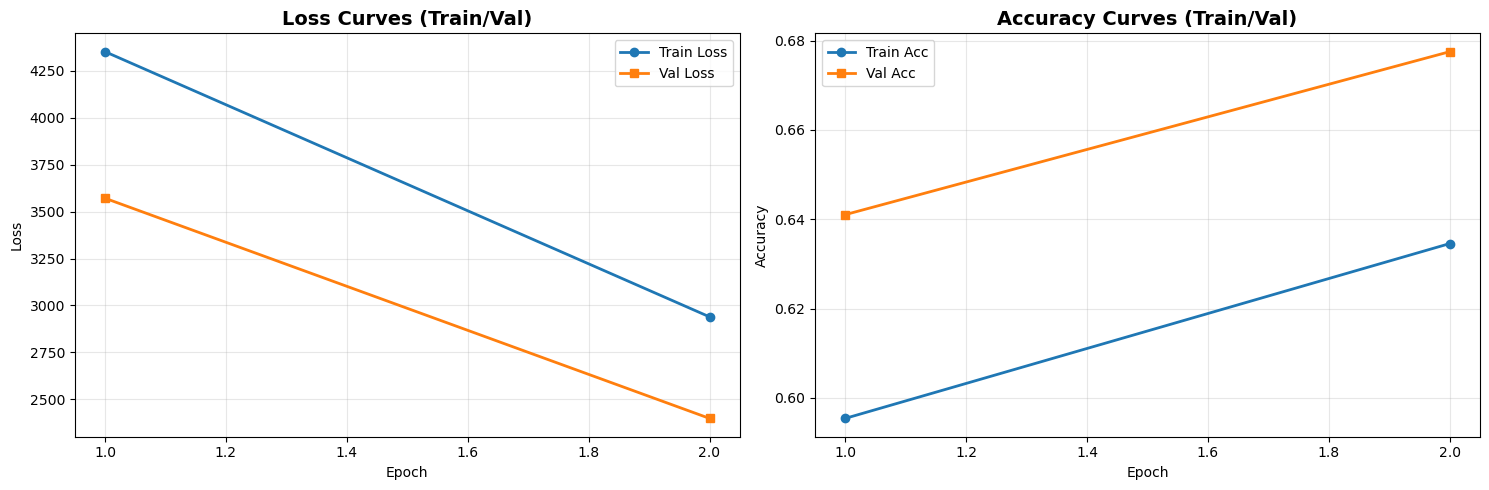


FINAL PERFORMANCE SUMMARY
  Metric     Train       Val
    Loss 2939.5400 2399.0705
Accuracy    0.6346    0.6775


In [321]:
# 3곡선 러닝커브 플롯
import matplotlib.pyplot as plt
import numpy as np

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 5))

epochs = np.arange(1, len(train_losses) + 1)

# Loss 곡선 (3 -> 2)
ax1.plot(epochs, train_losses, 'o-', label='Train Loss', linewidth=2)
ax1.plot(epochs, val_losses, 's-', label='Val Loss', linewidth=2)
# ax1.plot(epochs, test_losses, '^-', label='Test Loss', linewidth=2, color='red')
# ax1.set_title('Loss Curves (Train/Val/Test)', fontsize=14, fontweight='bold')
ax1.set_title('Loss Curves (Train/Val)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy 곡선 (3 -> 2)
ax2.plot(epochs, train_accs, 'o-', label='Train Acc', linewidth=2)
ax2.plot(epochs, val_accs, 's-', label='Val Acc', linewidth=2)
# ax2.plot(epochs, test_accs, '^-', label='Test Acc', linewidth=2, color='red')
# ax2.set_title('Accuracy Curves (Train/Val/Test)', fontsize=14, fontweight='bold')
ax2.set_title('Accuracy Curves (Train/Val)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 성능 요약표
print("\n" + "="*60)
print("FINAL PERFORMANCE SUMMARY")
print("="*60)
# summary_data = {
#     'Metric': ['Loss', 'Accuracy'],
#     'Train': [f"{train_losses[-1]:.4f}", f"{train_accs[-1]:.4f}"],
#     'Val': [f"{val_losses[-1]:.4f}", f"{val_accs[-1]:.4f}"],
#     'Test': [f"{test_losses[-1]:.4f}", f"{test_accs[-1]:.4f}"]
# }
summary_data = {
    'Metric': ['Loss', 'Accuracy'],
    'Train': [f"{train_losses[-1]:.4f}", f"{train_accs[-1]:.4f}"],
    'Val': [f"{val_losses[-1]:.4f}", f"{val_accs[-1]:.4f}"],
}
import pandas as pd
df = pd.DataFrame(summary_data)
print(df.to_string(index=False))


# 성능 측정하기

In [322]:
def generate_answer_from_qa(qa_ids, model, tokenizer,
                            max_len=50, temperature=1.0, top_k=20, device=None):
    if device is None:
        device = CFG["DEVICE"]

    model.eval()
    BOS_ID = 1
    EOS_ID = 2
    SEP_ID = EOS_ID    # EOS를 SEP로 재사용

    # 1) qa_ids 에서 SEP 위치 찾기
    try:
        sep_pos = qa_ids.index(SEP_ID)  # [BOS] 질문... [SEP] ... 이므로 한 개 존재한다고 가정
    except ValueError:
        sep_pos = len(qa_ids) - 1
        qa_ids = qa_ids + [SEP_ID]

    # 2) 질문+SEP 까지만 프롬프트로 사용
    prompt_ids = qa_ids[:sep_pos + 1]   # [BOS] 질문... [SEP]

    with torch.no_grad():
        ys = torch.tensor([prompt_ids], dtype=torch.long, device=device)  # [1, L_prompt]

        for _ in range(max_len):
            # 학습 때와 동일한 방식으로 마스크 생성
            dec_mask = generate_masks(ys)   # ★ 여기

            # decoder-only forward (노트북의 model(decin, decmask) 버전)
            logits_all, _ = model(ys, dec_mask)   # [1, L, vocab]
            logits = logits_all[0, -1, :] / temperature

            if top_k > 0:
                topk_logits, topk_idx = torch.topk(logits, top_k)
                mask = torch.full_like(logits, float('-inf'))
                logits = mask.scatter(0, topk_idx, topk_logits)

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)
            next_id = next_token.item()

            ys = torch.cat([ys, next_token.unsqueeze(0)], dim=1)

            if next_id == EOS_ID:
                break

        all_ids = ys[0].tolist()

        # [SEP] 다음부터가 답
        answer_ids = all_ids[sep_pos + 1:]

        # 마지막 EOS 제거
        if len(answer_ids) > 0 and answer_ids[-1] == EOS_ID:
            answer_ids = answer_ids[:-1]

        gen_answer = tokenizer.DecodeIds(answer_ids) if len(answer_ids) > 0 else ""
        full_decoded = tokenizer.DecodeIds(all_ids)

        return gen_answer, full_decoded


In [324]:
for i in [0, 10, 100]:
    # 디버깅용: 질문/정답 실제 텍스트
    q = tokenizer.decode_ids(sum([s[1:-1] for s in enc_train[i]], []))
    a = tokenizer.decode_ids(sum([s[1:-1] for s in dec_train[i]], []))

    gen_answer, full = generate_answer_from_qa(
        qa_train[i], transformer, tokenizer,
        max_len=50, temperature=1.0, top_k=20
    )

    print(f"=== 샘플 {i} ===")
    print("질문:", q)
    print("정답:", a)
    print("생성 답:", repr(gen_answer))
    print("전체:", full)
    print("-" * 50)


=== 샘플 0 ===
질문: 엄청 로맨틱 해
정답: 생각 만해 도 달콤하네요 .
생성 답: '한'
전체: 엄청 로맨틱 해 한
--------------------------------------------------
=== 샘플 10 ===
질문: 가족 들 이랑 어디 가지 ?
정답: 온 가족 이 모두 마음 에 드는 곳 으로 가보세요 .
생성 답: ''
전체: 가족 들 이랑 어디 가지 ?
--------------------------------------------------
=== 샘플 100 ===
질문: 연애 감흥 이 점점 사라져
정답: 연애 의 모습 이 다양한 거 예요 .
생성 답: ''
전체: 연애 감흥 이 점점 사라져
--------------------------------------------------


In [323]:
i = 0
qa_ids = qa_train[i]  # [BOS] Q SEP A EOS
gen_answer, full = generate_answer_from_qa(
    qa_ids, transformer, tokenizer,
    max_len=50, temperature=1.0, top_k=20, device=CFG["DEVICE"]
)

print("질문/정답/생성:")
print("QA ids:", qa_ids)
print("Full decoded:", full)
print("Gen answer:", repr(gen_answer))


질문/정답/생성:
QA ids: [1, 764, 123, 2996, 1358, 36, 2, 31, 1420, 24, 180, 2929, 1069, 7, 5, 2]
Full decoded: 엄청 로맨틱 해 한
Gen answer: '한'


In [327]:
i = 0  # 보고 싶은 질문-답 쌍 인덱스
question_text = tokenizer.decode_ids(enc_train[i][0])   # 질문 첫 문장 복원
ref_answer_text = tokenizer.decode_ids(dec_train[i][0]) # 정답 첫 문장 복원

gen_answer, full_text = generate_answer_from_question(
    enc_train[i],
    transformer,
    tokenizer,
    max_len=30,
    temperature=0.8,
    top_k=10
)

print("=== 샘플", i, "===")
print("질문:", question_text)
print("정답:", ref_answer_text)
print("생성 답:", gen_answer)
print("전체 시퀀스(질문+생성):", full_text)


=== 샘플 0 ===
질문: 엄청
정답: 생각
생성 답: 한
전체 시퀀스(질문+생성): 엄청 로맨틱 해 한
